In [26]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import calendar

In [27]:
iyear=1960
fyear=2024
nx=10;ny=10
dom='GRp'
dom_NST = 'GRi'
year_NST = '2014'

In [28]:
ds_grM= xr.open_dataset(f'/home/santolam/NST.{year_NST}.01.01.00.{dom_NST}.nc')
LONS=ds_grM.LON[ny:-ny,nx:-nx].values
LATS=ds_grM.LAT[ny:-ny,nx:-nx].values
dsSH=ds_grM.SH[ny:-ny,nx:-nx]
latS=LATS.min(); latN=LATS.max()
lonW=LONS.min(); lonE=LONS.max()

elev = dsSH
elev = elev.rename({'x': 'X', 'y': 'Y'})

In [29]:
TTZ = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/TT_monmean_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['TT'][:,0,:,:] # 0 = first pressure level at surface

#Domain & period def
TTZ = TTZ.rename({'TIME': 'time'})
TTZ = TTZ[:,ny:-ny,nx:-nx].sel(time=slice(str(iyear),str(fyear)))

In [30]:
# Altitude bands per 250 m
elev_bands = np.arange(0, 8001, 250)

#Grille pas exactement les mêmes valeurs des fois à ,e-5 près 
elev = elev.assign_coords({
    "X": TTZ.X,
    "Y": TTZ.Y
})

# t2m mean per band of 250 m
TTZ_bands = TTZ.groupby_bins(elev, bins=elev_bands).mean()

/home/bricej/micromamba/stageM2_micro/lib/python3.10/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


In [31]:
TTZ_bands

<xarray.DataArray 'TT' (time: 780, SH_bins: 32)> Size: 100kB
dask.array<where, shape=(780, 32), dtype=float32, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 6kB 1960-01-16T12:00:00 ... 2024-12-16T12:...
  * SH_bins  (SH_bins) interval[int64, right] 512B (0, 250] ... (7750, 8000]
    ATMLAY   float32 4B 0.9995
Attributes:
    long_name:     Temperature
    units:         C
    cell_methods:  TIME: mean
    history:       From ICE.p48.1950.01.01-31

In [32]:
TTZ_bands.isel(time=0).isel(SH_bins = 0).values

array(nan, dtype=float32)

In [33]:
elev_bands = np.arange(0, 8001, 250)
y_vals = elev_bands[1:]   # 250, 500, 750, ...

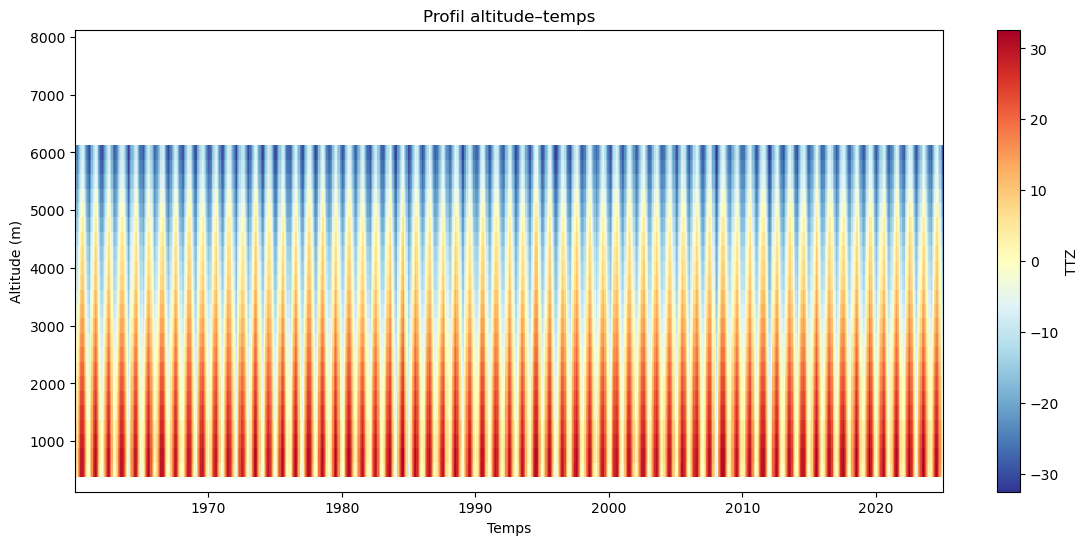

In [34]:
fig, ax = plt.subplots(figsize=(14, 6))

im = ax.pcolormesh(
    TTZ.time,
    y_vals,
    TTZ_bands.values.T,
    cmap="RdYlBu_r",
    shading="auto"
)

plt.colorbar(im, ax=ax, label="TTZ")

ax.set_xlabel("Temps")
ax.set_ylabel("Altitude (m)")
ax.set_title("Profil altitude–temps")

plt.show()

In [35]:
TTZ_bands = TTZ_bands.sel(time=slice(str(2000),str(2001)))

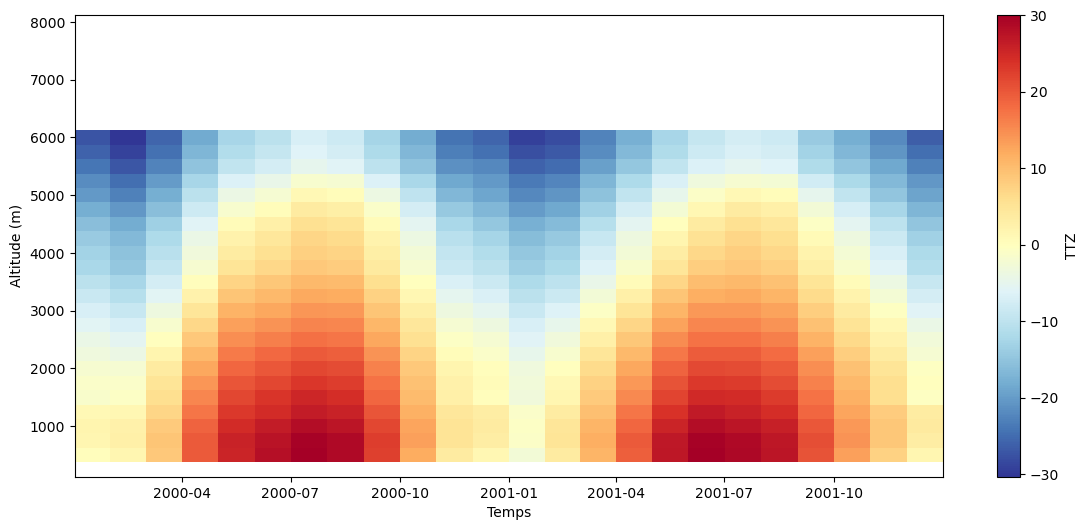

In [36]:
fig, ax = plt.subplots(figsize=(14, 6))

im = ax.pcolormesh(
    TTZ_bands.time,
    y_vals,
    TTZ_bands.values.T,
    cmap="RdYlBu_r",
    shading="auto"
)

plt.colorbar(im, ax=ax, label="TTZ")

ax.set_xlabel("Temps")
ax.set_ylabel("Altitude (m)")

plt.show()

In [37]:
TTZ_bands

<xarray.DataArray 'TT' (time: 24, SH_bins: 32)> Size: 3kB
dask.array<getitem, shape=(24, 32), dtype=float32, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 192B 2000-01-16T12:00:00 ... 2001-12-16T12...
  * SH_bins  (SH_bins) interval[int64, right] 512B (0, 250] ... (7750, 8000]
    ATMLAY   float32 4B 0.9995
Attributes:
    long_name:     Temperature
    units:         C
    cell_methods:  TIME: mean
    history:       From ICE.p48.1950.01.01-31

In [39]:
zcenters = np.array([interval.mid for interval in TTZ_bands.SH_bins.values])

Tz = TTZ_bands.values   # shape (time, elevation_bin)

freezing = np.full(Tz.shape[0], np.nan)

for t in range(Tz.shape[0]):

    profile = Tz[t, :]
    valid = ~np.isnan(profile)

    z = zcenters[valid]
    Tprof = profile[valid]

    if len(Tprof) < 2:
        continue

    sign = np.sign(Tprof)
    cross = np.where(np.diff(sign) != 0)[0]

    if len(cross) > 0:
        i = cross[0]  # première intersection (plus basse)

        z1, z2 = z[i], z[i+1]
        T1, T2 = Tprof[i], Tprof[i+1]

        freezing[t] = z1 + (0 - T1) * (z2 - z1) / (T2 - T1)

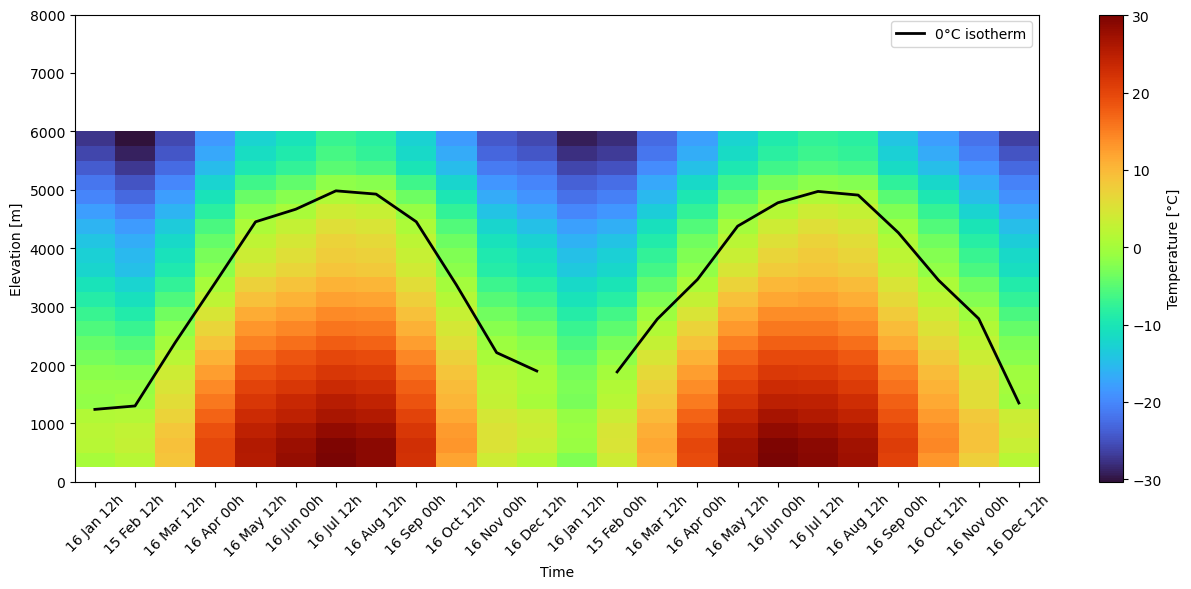

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

time = pd.to_datetime(TTZ_bands.time.values)
time_num = np.arange(len(time))

plt.figure(figsize=(13,6))

plt.pcolormesh(
    time_num,
    zcenters,
    Tz.T,
    shading="auto",
    cmap="turbo"
)

# ticks
tick_mask = (time.hour % 12 == 0)
xticks = np.where(tick_mask)[0]
labels = time[tick_mask].strftime("%d %b %Hh")

plt.xticks(xticks, labels, rotation=45)

plt.ylabel("Elevation [m]")
plt.xlabel("Time")
plt.colorbar(label="Temperature [°C]")

# FLH
plt.plot(time_num, freezing, color="k", lw=2, label="0°C isotherm")

plt.legend()
plt.tight_layout()
plt.show()